# Cloud IAM Risk Scoring

Rank synthetic cloud identities by privilege, exposure, credential hygiene, and suspicious activity.

**Safety and scope:** This project uses synthetic, non-sensitive telemetry for defensive analytics. It does not perform exploitation or execute malicious content.

## Goal

Train an explainable risk model and measure how many risky identities appear within the top review decile.


## Setup

The notebook is deterministic, runs offline, and implements the core analytical method directly with NumPy and Pandas so the modeling logic remains inspectable.


In [1]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

def sigmoid(values):
    clipped = np.clip(values, -30, 30)
    return 1.0 / (1.0 + np.exp(-clipped))

def split_indices(size, test_fraction=0.25):
    shuffled = rng.permutation(size)
    split_at = int(size * (1 - test_fraction))
    return shuffled[:split_at], shuffled[split_at:]

def standardize(train_values, test_values):
    mean = train_values.mean(axis=0)
    std = train_values.std(axis=0)
    std = np.where(std < 1e-9, 1.0, std)
    return (train_values - mean) / std, (test_values - mean) / std, mean, std

def fit_logistic(features, labels, steps=1400, learning_rate=0.08, l2=0.01):
    design = np.column_stack([np.ones(len(features)), features])
    weights = np.zeros(design.shape[1])
    for _ in range(steps):
        probabilities = sigmoid(design @ weights)
        gradient = design.T @ (probabilities - labels) / len(labels)
        gradient[1:] += l2 * weights[1:]
        weights -= learning_rate * gradient
    return weights

def predict_probability(features, weights):
    design = np.column_stack([np.ones(len(features)), features])
    return sigmoid(design @ weights)

def classification_metrics(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    tp = int(((labels == 1) & (predictions == 1)).sum())
    tn = int(((labels == 0) & (predictions == 0)).sum())
    fp = int(((labels == 0) & (predictions == 1)).sum())
    fn = int(((labels == 1) & (predictions == 0)).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    accuracy = (tp + tn) / max(len(labels), 1)
    return pd.Series({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


## Steps

### 1. Generate synthetic IAM posture data


In [2]:
principal_count = 1900
admin_privilege = rng.binomial(1, 0.09, principal_count)
wildcard_actions = rng.poisson(0.6, principal_count)
wildcard_resources = rng.poisson(0.8, principal_count)
external_trust = rng.binomial(1, 0.11, principal_count)
mfa_disabled = rng.binomial(1, 0.16, principal_count)
access_key_age_days = rng.gamma(2.0, 55.0, principal_count).clip(0, 500)
unused_days = rng.gamma(1.7, 35.0, principal_count).clip(0, 365)
anomalous_api_calls = rng.poisson(0.5, principal_count)

risky_probability = sigmoid(
    -5.7
    + 1.55 * admin_privilege
    + 0.42 * wildcard_actions
    + 0.32 * wildcard_resources
    + 1.05 * external_trust
    + 0.90 * mfa_disabled
    + 0.004 * access_key_age_days
    + 0.003 * unused_days
    + 0.55 * anomalous_api_calls
)
confirmed_risky = rng.binomial(1, risky_probability)

iam_principals = pd.DataFrame({
    "admin_privilege": admin_privilege,
    "wildcard_actions": wildcard_actions,
    "wildcard_resources": wildcard_resources,
    "external_trust": external_trust,
    "mfa_disabled": mfa_disabled,
    "access_key_age_days": access_key_age_days,
    "unused_days": unused_days,
    "anomalous_api_calls": anomalous_api_calls,
    "confirmed_risky": confirmed_risky,
})

print("Principal count:", len(iam_principals))
print("Confirmed-risk rate:", round(iam_principals["confirmed_risky"].mean(), 3))
print(iam_principals.head(6).round(2).to_string(index=False))


Principal count: 1900
Confirmed-risk rate: 0.026
 admin_privilege  wildcard_actions  wildcard_resources  external_trust  mfa_disabled  access_key_age_days  unused_days  anomalous_api_calls  confirmed_risky
               0                 1                   1               0             0               103.22        64.70                    1                0
               0                 1                   0               0             0                44.92        46.36                    0                0
               0                 1                   2               1             0               176.67        13.47                    0                0
               0                 0                   0               0             0                33.33        17.30                    0                0
               0                 0                   1               0             0               112.35        66.95                    0                0
         

### 2. Model, rank, and explain identity risk


In [3]:
feature_names = [column for column in iam_principals.columns if column != "confirmed_risky"]
train_rows, test_rows = split_indices(len(iam_principals))
train_values = iam_principals.loc[train_rows, feature_names].to_numpy(float)
test_values = iam_principals.loc[test_rows, feature_names].to_numpy(float)
train_labels = iam_principals.loc[train_rows, "confirmed_risky"].to_numpy(int)
test_labels = iam_principals.loc[test_rows, "confirmed_risky"].to_numpy(int)

train_scaled, test_scaled, _, _ = standardize(train_values, test_values)
iam_weights = fit_logistic(train_scaled, train_labels)
iam_probability = predict_probability(test_scaled, iam_weights)
iam_prediction = (iam_probability >= 0.5).astype(int)
iam_metrics = classification_metrics(test_labels, iam_prediction)

ranked_identities = iam_principals.loc[test_rows].copy()
ranked_identities["risk_probability"] = iam_probability
ranked_identities = ranked_identities.sort_values("risk_probability", ascending=False)
review_count = max(1, int(len(ranked_identities) * 0.10))
top_decile_recall = (
    ranked_identities.head(review_count)["confirmed_risky"].sum()
    / max(ranked_identities["confirmed_risky"].sum(), 1)
)
iam_importance = pd.DataFrame({
    "feature": feature_names,
    "standardized_weight": iam_weights[1:],
}).sort_values("standardized_weight", ascending=False)

print("Test metrics:")
print(iam_metrics.round(3).to_string())
print("\nRisk captured in top review decile:", round(top_decile_recall, 3))
print("\nFeature weights:")
print(iam_importance.round(3).to_string(index=False))
print("\nHighest-risk identities:")
print(ranked_identities.head(8).round(3).to_string(index=False))


Test metrics:
accuracy       0.971
precision      0.000
recall         0.000
f1             0.000
tp             0.000
fp             0.000
tn           461.000
fn            14.000

Risk captured in top review decile: 0.571

Feature weights:
            feature  standardized_weight
   wildcard_actions                0.355
access_key_age_days                0.336
 wildcard_resources                0.309
    admin_privilege                0.255
anomalous_api_calls                0.211
     external_trust                0.130
       mfa_disabled                0.126
        unused_days                0.060

Highest-risk identities:
 admin_privilege  wildcard_actions  wildcard_resources  external_trust  mfa_disabled  access_key_age_days  unused_days  anomalous_api_calls  confirmed_risky  risk_probability
               1                 3                   1               1             0              140.410      304.837                    0                0             0.229
            

## Visual Insights & ML Extension

The original transparent method remains intact. This extension adds an explicit visual story, a stronger scikit-learn benchmark, and analyst-focused interpretation. All evaluation uses held-out or label-free synthetic examples as appropriate.

**Reading the results:** model scores describe this generated dataset only. They are not production performance claims and should not replace temporal validation, calibration, drift checks, or human review.


Model comparison (held-out data):
                     roc_auc  average_precision  f1_at_0_5
model                                                     
Logistic regression    0.709              0.134      0.155
Random forest          0.613              0.057      0.053

Analyst takeaways:
- Best average precision: Logistic regression (0.134).
- The highest-scored 10% is 3.6× denser in positives than the test-set baseline.
- Strongest random-forest driver: access key age days.
- Treat these synthetic benchmarks as a workflow example; production thresholds require temporal validation and drift monitoring.


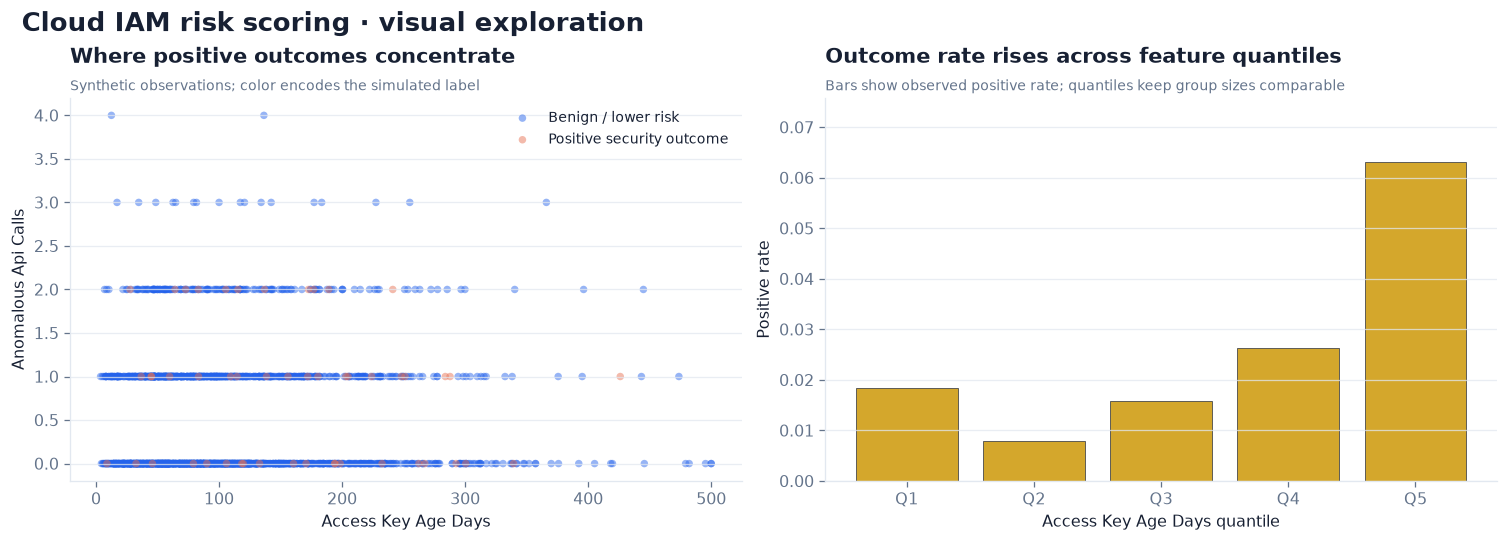

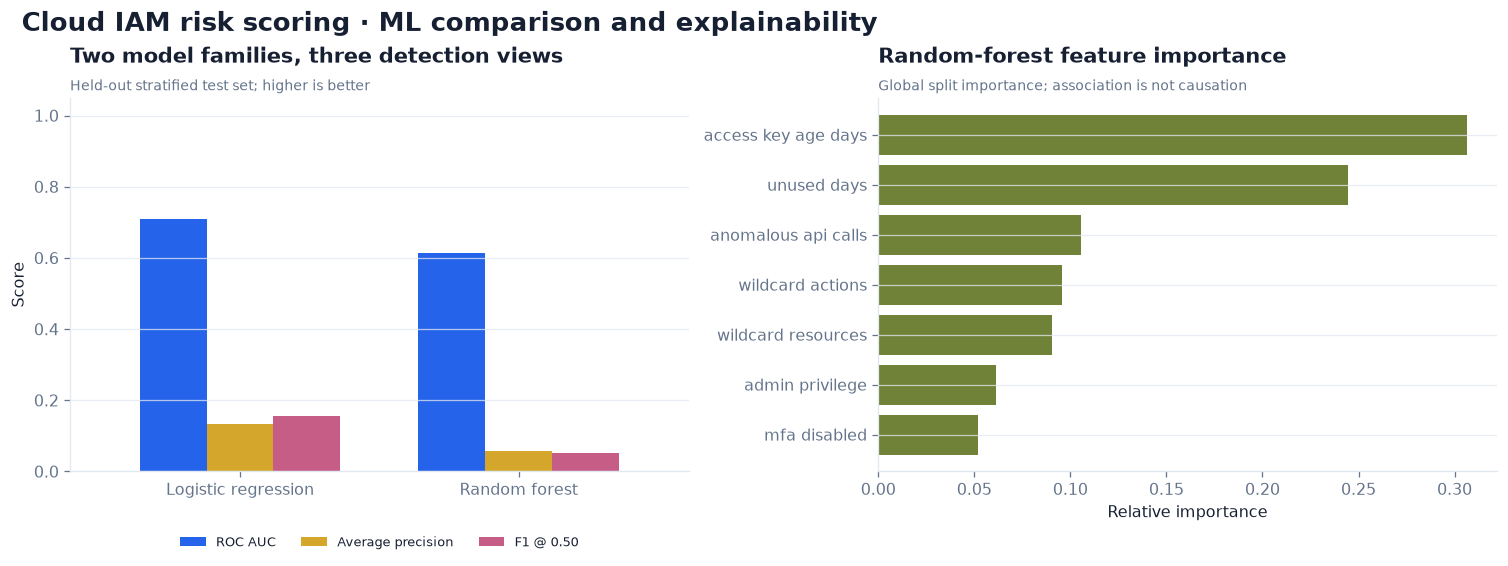

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 42)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def binary_model_comparison(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.28,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows = []
    probabilities = {}
    fitted = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

model_frame = iam_principals.copy()
ml_features = model_frame.drop(columns=["confirmed_risky"]).select_dtypes(include=[np.number])
ml_labels = model_frame["confirmed_risky"].to_numpy(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for class_value, color, class_name in [
    (0, PALETTE["blue"], "Benign / lower risk"),
    (1, PALETTE["orange"], "Positive security outcome"),
]:
    subset = model_frame[model_frame["confirmed_risky"] == class_value]
    axes[0].scatter(
        subset["access_key_age_days"], subset["anomalous_api_calls"],
        s=22, alpha=0.48, color=color, edgecolors="none", label=class_name,
    )
polish_axis(
    axes[0],
    "Where positive outcomes concentrate",
    "Synthetic observations; color encodes the simulated label",
    "Access Key Age Days",
    "Anomalous Api Calls",
)
axes[0].legend(frameon=False, fontsize=9)

risk_bins = pd.qcut(model_frame["access_key_age_days"], q=5, duplicates="drop")
rate_by_bin = model_frame.groupby(risk_bins, observed=True)["confirmed_risky"].agg(["mean", "size"])
axes[1].bar(
    range(len(rate_by_bin)), rate_by_bin["mean"],
    color=PALETTE["gold"], edgecolor=PALETTE["ink"], linewidth=0.4,
)
axes[1].set_xticks(range(len(rate_by_bin)), [f"Q{index + 1}" for index in range(len(rate_by_bin))])
axes[1].set_ylim(0, max(0.05, rate_by_bin["mean"].max() * 1.2))
polish_axis(
    axes[1],
    "Outcome rate rises across feature quantiles",
    "Bars show observed positive rate; quantiles keep group sizes comparable",
    "Access Key Age Days quantile",
    "Positive rate",
)
fig.suptitle("Cloud IAM risk scoring · visual exploration", fontsize=16, fontweight="bold", x=0.01, ha="left")

model_comparison, fitted_models, model_probabilities, comparison_labels = binary_model_comparison(
    ml_features, ml_labels
)
best_model_name = model_comparison["average_precision"].idxmax()
best_probability = model_probabilities[best_model_name]
review_count = max(1, int(len(best_probability) * 0.10))
top_positions = np.argsort(best_probability)[-review_count:]
comparison_labels_array = np.asarray(comparison_labels)
base_rate = float(comparison_labels_array.mean())
top_rate = float(comparison_labels_array[top_positions].mean())
top_decile_lift = top_rate / max(base_rate, 1e-9)

forest = fitted_models["Random forest"]
feature_importance = pd.Series(
    forest.feature_importances_, index=ml_features.columns, name="importance"
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
metric_colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["pink"]]
comparison_display = model_comparison.rename(columns={
    "roc_auc": "ROC AUC",
    "average_precision": "Average precision",
    "f1_at_0_5": "F1 @ 0.50",
})
comparison_display.plot(kind="bar", ax=axes[0], color=metric_colors, width=0.72)
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14))
polish_axis(
    axes[0],
    "Two model families, three detection views",
    "Held-out stratified test set; higher is better",
    "",
    "Score",
)

top_importance = feature_importance.head(7).sort_values()
axes[1].barh(top_importance.index.str.replace("_", " "), top_importance.values, color=PALETTE["olive"])
polish_axis(
    axes[1],
    "Random-forest feature importance",
    "Global split importance; association is not causation",
    "Relative importance",
    "",
)
fig.suptitle("Cloud IAM risk scoring · ML comparison and explainability", fontsize=16, fontweight="bold", x=0.01, ha="left")

print("Model comparison (held-out data):")
print(model_comparison.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- Best average precision: {best_model_name} ({model_comparison.loc[best_model_name, 'average_precision']:.3f}).")
print(f"- The highest-scored 10% is {top_decile_lift:.1f}× denser in positives than the test-set baseline.")
print(f"- Strongest random-forest driver: {feature_importance.index[0].replace('_', ' ')}.")
print("- Treat these synthetic benchmarks as a workflow example; production thresholds require temporal validation and drift monitoring.")


## Checks


In [5]:
assert 0.02 < iam_principals["confirmed_risky"].mean() < 0.50
assert top_decile_recall >= 0.30
assert ranked_identities["risk_probability"].is_monotonic_decreasing
assert ranked_identities["risk_probability"].between(0, 1).all()
print("Checks passed: plausible class balance, useful review concentration, and bounded sorted scores.")


Checks passed: plausible class balance, useful review concentration, and bounded sorted scores.


## Next Steps

        - Map features to AWS, Azure, or GCP identity and policy schemas.
- Add toxic permission combinations and resource sensitivity.
- Separate remediation priority from model probability and require owner review before changes.
